# 4. Survival Analysis

**Purpose:** communicate full-cohort survival risk and compare survival models across feature sets.

**Key distinction:** full survival is for absolute risk; strict/competing survival is for comparability with classification.

In [1]:
from pathlib import Path
import sys
import subprocess
import pandas as pd
import numpy as np
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
VENV_PY = ROOT / '.venv' / 'Scripts' / 'python.exe'
PIPELINE_PY = VENV_PY if VENV_PY.exists() else Path(sys.executable)
FEATURE_SETS = [
    'CV17', 'CV17_THY26', 'CV17_BIN', 'CV17_ORD',
    'CV17_CONT', 'CV17_CAT', 'CV17_RATIO', 'CV17_RATIO_ONLY'
]

def read_csv(name, folder=DATA, **kwargs):
    path = folder / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def show_image(path, width=850):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing figure: {path}')

def run_step(step, force=False):
    cmd = [str(PIPELINE_PY), str(ROOT / 'run_pipeline.py'), '--step', step]
    if force:
        cmd.append('--force')
    print('Running:', ' '.join(cmd))
    subprocess.run(cmd, cwd=ROOT, check=True)

def pct(x):
    return f'{100*x:.1f}%'

In [ ]:
RUN_PIPELINE_STEPS = True
if RUN_PIPELINE_STEPS:
    run_step('survival', force=False)
    run_step('survival_cohort', force=False)
else:
    print('Using existing survival artefacts. Set RUN_PIPELINE_STEPS=True to regenerate with .venv.')

Running: c:\Users\ileni\ml4cad\.venv\Scripts\python.exe c:\Users\ileni\ml4cad\run_pipeline.py --step survival


## 4.1 Full-cohort absolute risk

Kaplan-Meier gives net risk; Aalen-Johansen accounts for non-CVD deaths as competing events.

### survival_summary.csv

,km_s7,km_f7,aj_f7,km_f7_for_aj,km_minus_aj_abs,km_minus_aj_relative_pct
0,0.874428,0.125572,0.117243,0.125572,0.008329,7.104304


### risk_stratification_summary.csv

,risk_group,n,cvd_death_risk_7y_1km,logrank_low_vs_high_p,logrank_global_p
0,Low,2688,0.022720,1.220926e-167,1.176788e-210
1,Medium,2687,0.082548,1.220926e-167,1.176788e-210
2,High,2688,0.295852,1.220926e-167,1.176788e-210


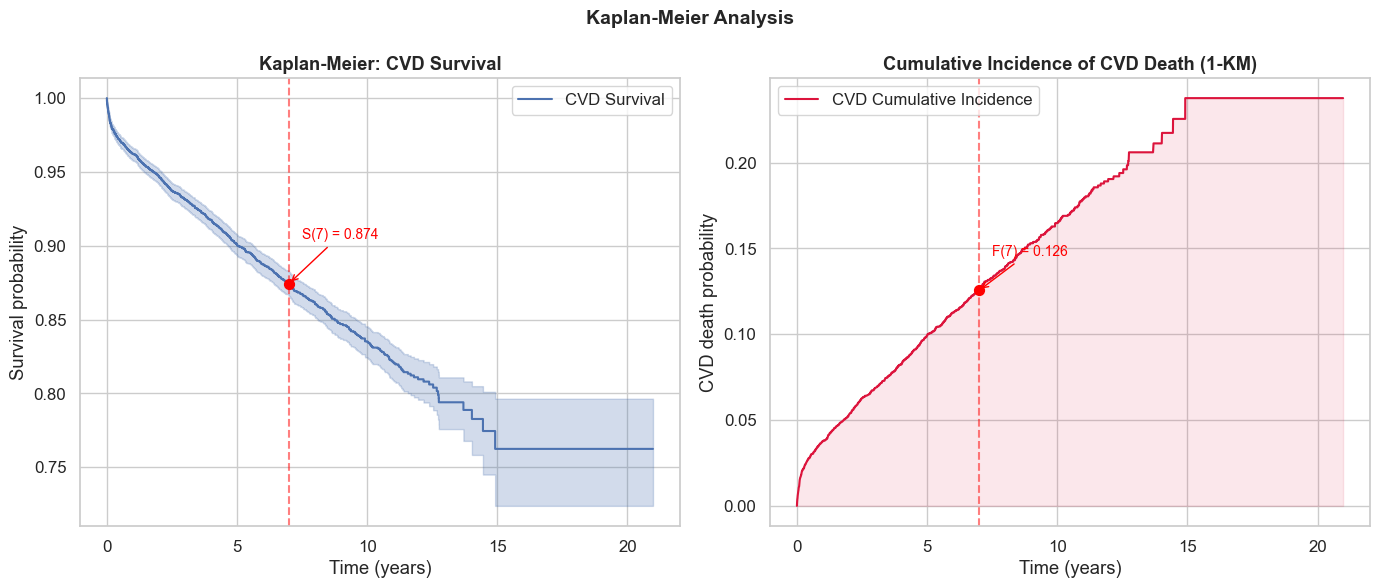

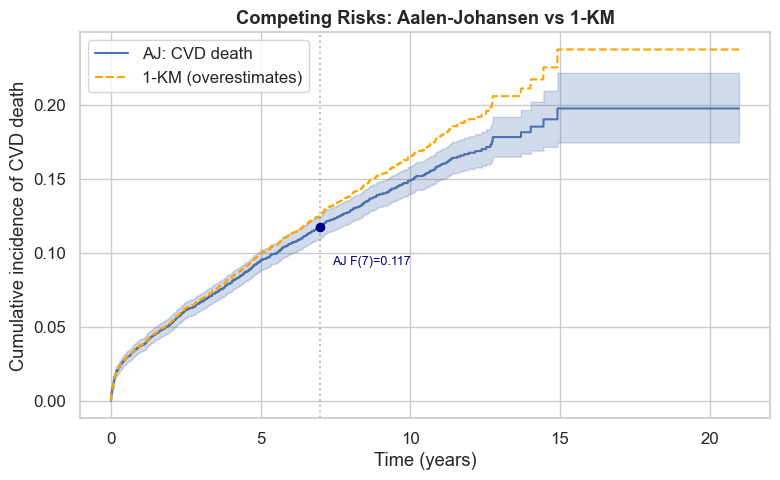

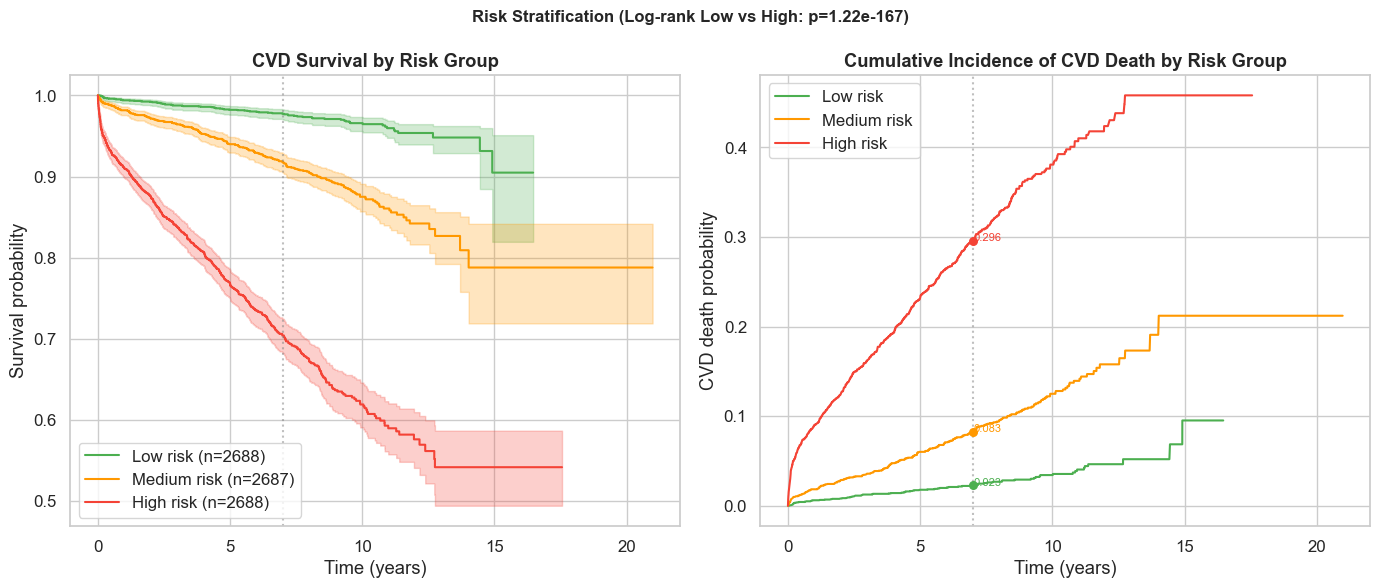

In [ ]:
for name in ['survival_summary.csv', 'risk_stratification_summary.csv']:
    path = REPORTS / name
    if path.exists():
        display(Markdown(f'### {name}'))
        display(pd.read_csv(path))
show_image(FIGURES / 'km_cumulative_incidence.png', width=850)
show_image(FIGURES / 'aalen_johansen.png', width=750)
show_image(FIGURES / 'risk_stratification.png', width=850)

## 4.2 c-index matrix: cohorts ? feature sets ? models

This is the survival analogue of the classification comparison.

,cohort,rows,expected,complete
0,full,32,32,True
1,strict,16,16,True
2,competing,16,16,True


,cohort,feature_set,model,c_index_mean,c_index_std
52,competing,CV17_BIN,CoxPH,0.784616,0.013602
58,competing,CV17_CAT,CoxPH,0.783751,0.012870
50,competing,CV17_THY26,CoxPH,0.783334,0.012357
60,competing,CV17_RATIO,CoxPH,0.783300,0.012522
48,competing,CV17,CoxPH,0.783078,0.012905
56,competing,CV17_CONT,CoxPH,0.783075,0.012091
54,competing,CV17_ORD,CoxPH,0.783012,0.012883
62,competing,CV17_RATIO_ONLY,CoxPH,0.782963,0.012174
9,full,CV17_BIN,CoxNet,0.793939,0.012292
21,full,CV17_CAT,CoxNet,0.793393,0.012319


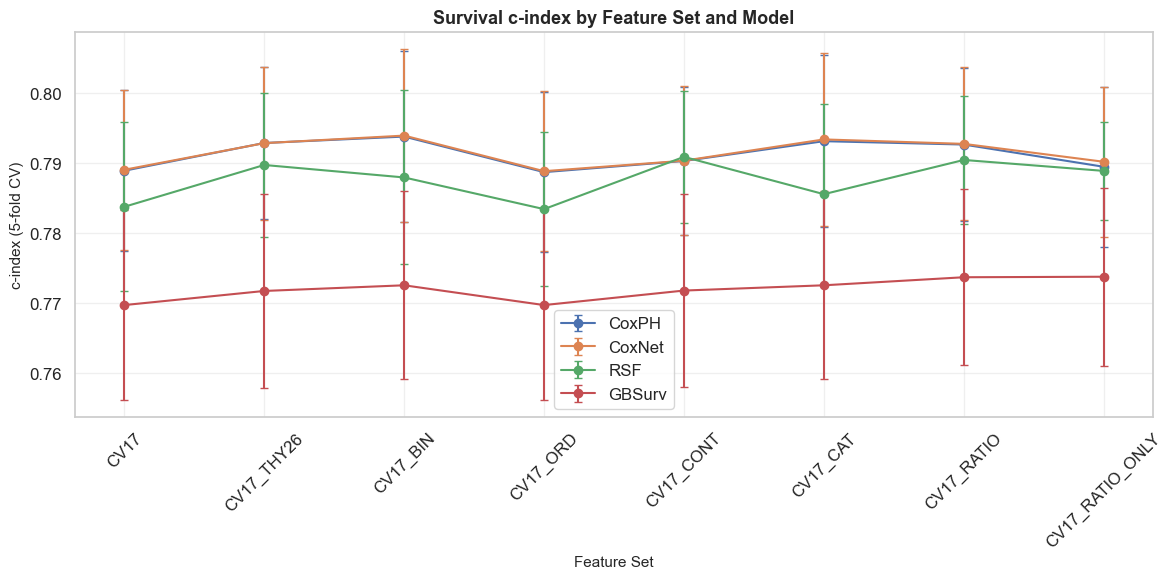

In [ ]:
surv = read_csv('results_surv.csv') if (DATA / 'results_surv.csv').exists() else pd.DataFrame()
if not surv.empty:
    expected_rows = {'full': 8*4, 'strict': 8*2, 'competing': 8*2}
    display(pd.DataFrame([{'cohort': k, 'rows': int((surv['cohort']==k).sum()), 'expected': v, 'complete': int((surv['cohort']==k).sum()) == v} for k, v in expected_rows.items()]))
    best = surv.sort_values('c_index_mean', ascending=False).groupby(['cohort','feature_set']).head(1)
    display(best[['cohort','feature_set','model','c_index_mean','c_index_std']].sort_values(['cohort','c_index_mean'], ascending=[True, False]))
else:
    print('No survival CV results.')
show_image(FIGURES / 'survival_cindex.png', width=850)

## 4.3 Cox interpretation and proportional hazards checks

Full-cohort Cox outputs address clinical interpretation on the full survival cohort. Cohort-level Cox outputs are generated for strict/competing and all feature sets after the latest code update.

In [ ]:
for name in ['cox_univariate.csv', 'cox_multivariate.csv', 'cox_cohort_multivariate.csv', 'cox_cohort_schoenfeld.csv']:
    path = REPORTS / name
    display(Markdown(f'### {name}'))
    if path.exists():
        df = pd.read_csv(path)
        display(df.head(30))
        print(f'rows={len(df)} columns={list(df.columns)}')
    else:
        print('Not generated yet.')

### cox_univariate.csv

,feature,HR,p,CI_lo,CI_hi,significant
0,AFib,1.780260,6.084517e-17,1.555191,2.037901,True
1,Acute_MI,1.840561,1.027505e-10,1.529677,2.214628,True
2,Age,2.295515,1.071308e-87,2.114705,2.491785,True
3,Angina,0.867324,2.401296e-02,0.766473,0.981445,True
4,Angiography,0.803626,5.912656e-04,0.709395,0.910373,True
5,Diabetes,1.896823,1.565623e-21,1.662838,2.163733,True
6,Dyslipidemia,0.611126,8.214665e-15,0.539688,0.692021,True
7,Euthyroid,0.476324,9.358989e-32,0.420790,0.539187,True
8,Gender,1.123805,8.412811e-02,0.984395,1.282959,False
9,Hypertension,1.051952,4.315035e-01,0.927237,1.193441,False


rows=26 columns=['feature', 'HR', 'p', 'CI_lo', 'CI_hi', 'significant']


### cox_multivariate.csv

,covariate,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
0,Gender,0.034837,1.035451,0.075076,-0.112310,0.181984,0.893767,1.199595,0.0,0.464022,6.426318e-01,0.637936
1,Age,0.686368,1.986487,0.046307,0.595607,0.777128,1.814133,2.175216,0.0,14.822098,1.054391e-49,162.698066
2,Angina,-0.011852,0.988218,0.073800,-0.156497,0.132792,0.855134,1.142013,0.0,-0.160603,8.724062e-01,0.196928
3,Previous_CABG,0.270720,1.310908,0.100193,0.074345,0.467095,1.077179,1.595352,0.0,2.701984,6.892705e-03,7.180714
4,Previous_PCI,0.055916,1.057508,0.097125,-0.134446,0.246277,0.874200,1.279254,0.0,0.575709,5.648121e-01,0.824157
5,Previous_MI,0.231624,1.260646,0.080139,0.074554,0.388694,1.077403,1.475053,0.0,2.890269,3.849126e-03,8.021253
6,Acute_MI,0.410050,1.506893,0.101004,0.212085,0.608015,1.236252,1.836781,0.0,4.059719,4.913174e-05,14.312985
7,Angiography,-0.399158,0.670885,0.093535,-0.582483,-0.215833,0.558510,0.805870,0.0,-4.267484,1.976900e-05,15.626401
8,Vessels,0.210917,1.234810,0.044781,0.123149,0.298685,1.131053,1.348086,0.0,4.710019,2.476932e-06,18.623015
9,Ischemia,-0.098792,0.905931,0.083884,-0.263202,0.065618,0.768587,1.067818,0.0,-1.177722,2.389076e-01,2.065475


rows=25 columns=['covariate', 'coef', 'exp(coef)', 'se(coef)', 'coef lower 95%', 'coef upper 95%', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'cmp to', 'z', 'p', '-log2(p)']


### cox_cohort_multivariate.csv

Not generated yet.


### cox_cohort_schoenfeld.csv

Not generated yet.


## Take-home message

- Report full-cohort Aalen-Johansen for absolute CVD death risk.
- Use strict/competing survival only for head-to-head comparison with classification.
- Use Cox outputs for interpretation, but check proportional hazards assumptions before over-interpreting HRs.